In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

In [30]:
learning_rates = [1e-3]
filter_options = [(32, 64, 128),(64, 128, 256)]
WINDOW_SIZES = [512,1024]
STRIDES = [256]

EPOCHS = 30
BATCH_SIZE = 128

In [31]:
BASE_PATH = "/kaggle/input/datasets/nagasai524/anomaly-detection-in-helicopter/"

train_df = pd.read_csv(BASE_PATH + "train_df.csv",
                       header=None, skiprows=1, index_col=0)

validation_df = pd.read_csv(BASE_PATH + "validation_df.csv",
                            header=None, skiprows=1, index_col=0)

groundtruth_df = pd.read_csv(BASE_PATH + "dfvalid_groundtruth.csv")

X_train_raw = train_df.values
X_test_raw = validation_df.values
y_test_raw = groundtruth_df["anomaly"].values.astype(int)

In [32]:
X_train_signals, X_val_signals = train_test_split(
    X_train_raw,
    test_size=0.2,
    random_state=42
)

In [33]:
mu_train = np.mean(X_train_signals)
sigma_train = np.std(X_train_signals)
sigma_train = max(sigma_train, 1e-8)

X_train_signals = (X_train_signals - mu_train) / sigma_train
X_val_signals   = (X_val_signals   - mu_train) / sigma_train
X_test_raw      = (X_test_raw      - mu_train) / sigma_train

In [34]:
def create_windows_per_signal(data, window_size, stride):
    windows = []
    for signal in data:
        for start in range(0, len(signal) - window_size + 1, stride):
            windows.append(signal[start:start + window_size])
    return np.array(windows)

In [35]:
def build_autoencoder(window_size, f1, f2, f3, lr):

    inputs = layers.Input(shape=(window_size, 1))

    x = layers.Conv1D(f1, 7, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(f2, 7, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(f3, 7, padding="same", activation="relu")(x)
    encoded = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(f3, 7, padding="same", activation="relu")(encoded)
    x = layers.UpSampling1D(2)(x)

    x = layers.Conv1D(f2, 7, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)

    x = layers.Conv1D(f1, 7, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)

    outputs = layers.Conv1D(1, 7, padding="same", activation="linear")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")

    return model

In [36]:
def reconstruct_full_signal(signal, model, window_size, stride):

    length = len(signal)
    reconstructed = np.zeros(length)
    counts = np.zeros(length)

    for start in range(0, length - window_size + 1, stride):
        window = signal[start:start + window_size]
        window_input = window[np.newaxis, ..., np.newaxis]
        recon_window = model.predict(window_input, verbose=0)[0].flatten()

        reconstructed[start:start + window_size] += recon_window
        counts[start:start + window_size] += 1

    counts[counts == 0] = 1
    reconstructed /= counts

    return reconstructed

In [37]:
def compute_signal_scores(data, labels, model,
                          window_size, stride):

    signal_scores = []

    for signal in data:

        windows = []
        for start in range(0, len(signal) - window_size + 1, stride):
            windows.append(signal[start:start + window_size])

        windows = np.array(windows)[..., np.newaxis]

        recon = model.predict(windows, verbose=0)
        errors = np.mean((windows - recon) ** 2, axis=(1,2))

        score = np.mean(errors)
        signal_scores.append(score)

    return np.array(signal_scores), labels

In [38]:
param_grid = list(itertools.product(
    learning_rates,
    filter_options,
    WINDOW_SIZES,
    STRIDES
))

best_val_loss = np.inf
best_config = None
best_model = None

for lr, filters, window_size, stride in param_grid:

    f1_f, f2_f, f3_f = filters

    print(f"\nConfig: LR={lr}, Filters={filters}, "
          f"Window={window_size}, Stride={stride}")

    X_train = create_windows_per_signal(X_train_signals, window_size, stride)
    X_val   = create_windows_per_signal(X_val_signals,   window_size, stride)

    X_train = X_train[..., np.newaxis]
    X_val   = X_val[..., np.newaxis]

    model = build_autoencoder(window_size, f1_f, f2_f, f3_f, lr)

    history = model.fit(
        X_train,
        X_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, X_val),
        callbacks=[
            callbacks.EarlyStopping(
                patience=5,
                restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-6,
                verbose=1
            )
        ],
        verbose=0
    )

    val_loss = model.evaluate(X_val, X_val, verbose=0)

    print("Validation MSE:", val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = (lr, filters, window_size, stride)
        best_model = model


Config: LR=0.001, Filters=(32, 64, 128), Window=512, Stride=256

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Validation MSE: 0.0007862601196393371

Config: LR=0.001, Filters=(32, 64, 128), Window=1024, Stride=256

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Validation MSE: 0.002926571760326624

Config: LR=0.001, Filters=(64, 128, 256), Window=512, Stride=256


2026-02-17 11:11:55.824524: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng18{k11=0} for conv %cudnn-conv-bw-filter.4 = (f32[256,256,1,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,256,1,64]{3,2,1,0} %bitcast.4352, f32[128,256,1,64]{3,2,1,0} %bitcast.3863), window={size=1x7 pad=0_0x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/functional_3_1/conv1d_24_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-02-17 11:11:59.448867: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.624440349s
Tryi


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 30: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Validation MSE: 0.0005435966304503381

Config: LR=0.001, Filters=(64, 128, 256), Window=1024, Stride=256

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 28: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Validation MSE: 0.00039667857345193624


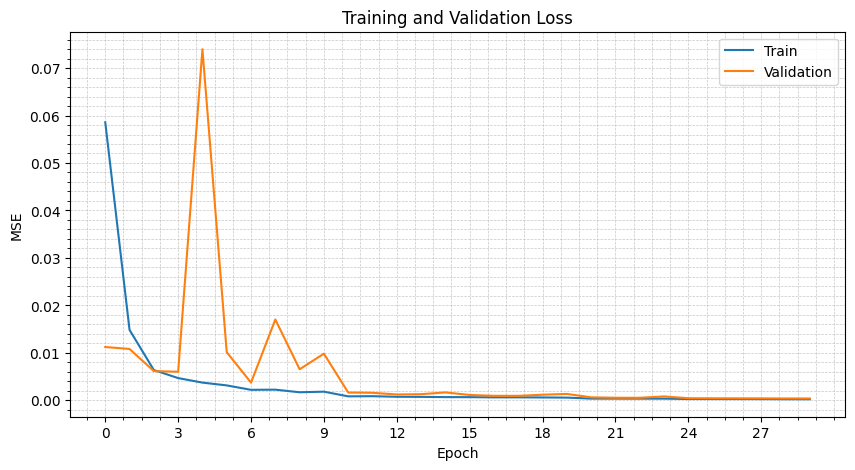

In [39]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train", "Validation"])

plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.minorticks_on()

epochs = len(history.history["loss"])
plt.xticks(range(0, epochs, max(1, epochs // 10)))

plt.show()

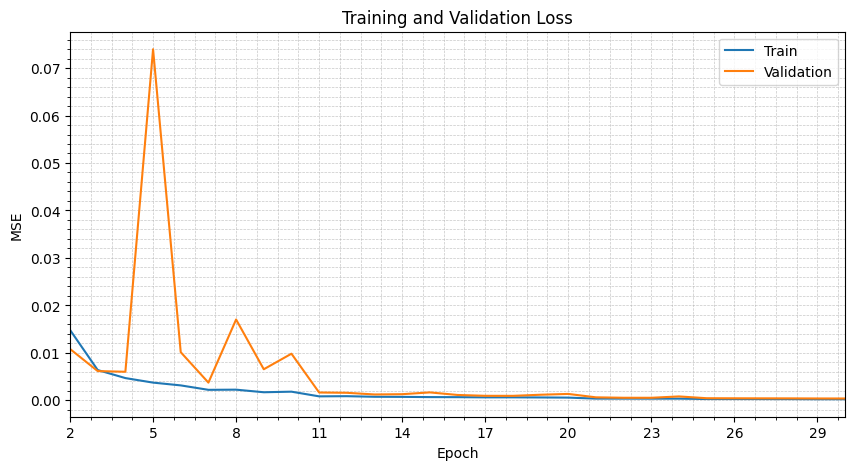

In [40]:
epochs = len(history.history["loss"])
x = range(1, epochs + 1)

plt.figure(figsize=(10,5))
plt.plot(x, history.history["loss"])
plt.plot(x, history.history["val_loss"])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train", "Validation"])

plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.minorticks_on()
plt.xticks(range(2, epochs + 1, max(1, epochs // 10)))
plt.xlim(2, epochs)

# rescale y to the visible data only
visible_loss = history.history["loss"][1:]
visible_val  = history.history["val_loss"][1:]
ymin = min(min(visible_loss), min(visible_val))
ymax = max(max(visible_loss), max(visible_val))
padding = (ymax - ymin) * 0.05
plt.ylim(ymin - padding, ymax + padding)

plt.show()

Best normal index: 214
Worst normal index: 449
Best anomaly index: 87
Worst anomaly index: 208

--- NORMAL SIGNALS ---


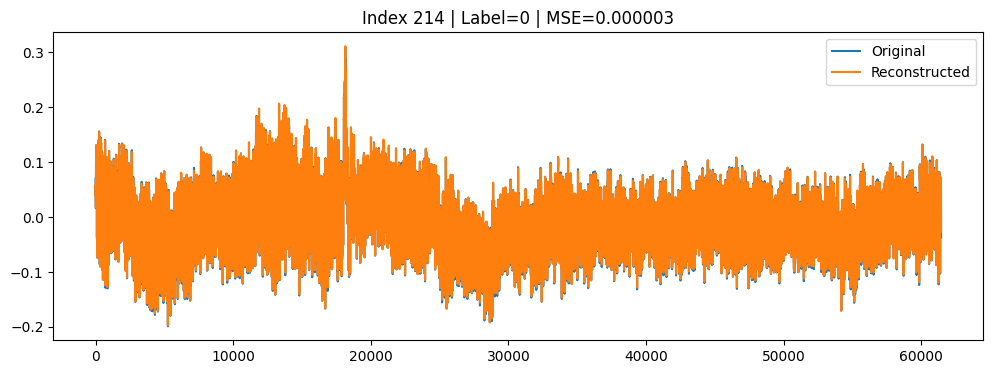

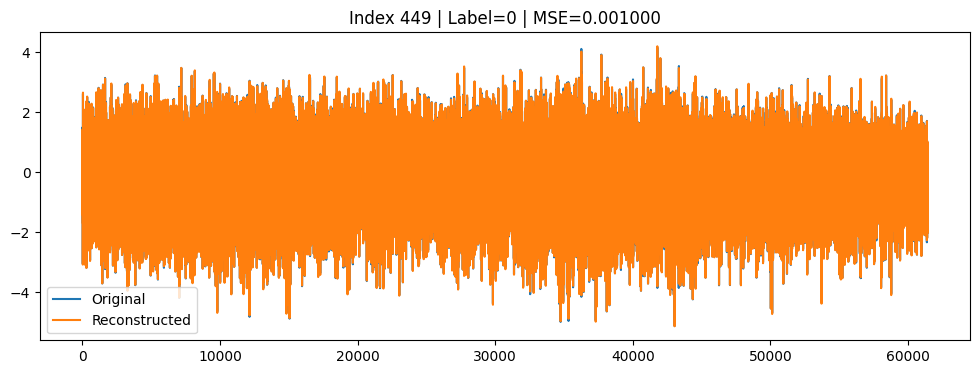


--- ANOMALY SIGNALS ---


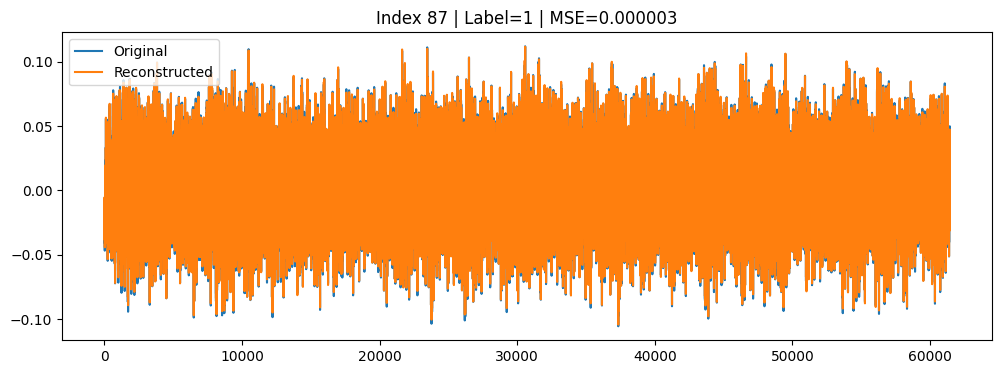

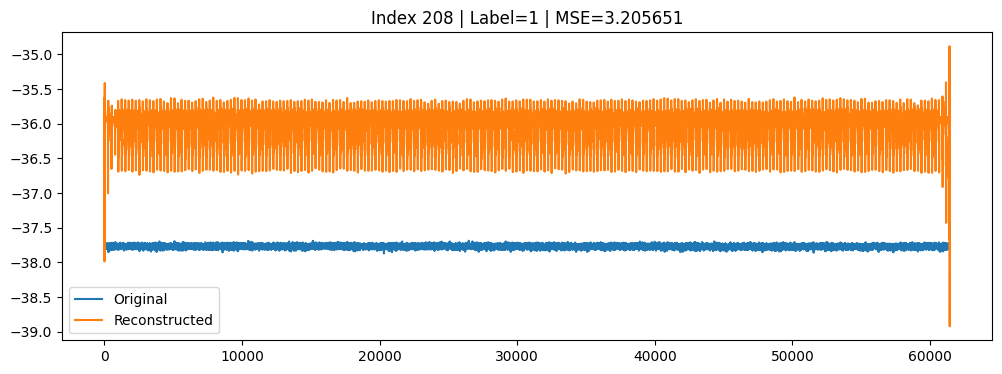

In [41]:
# Compute signal-level scores
test_scores, test_labels = compute_signal_scores(
    X_test_raw,
    y_test_raw,
    best_model,
    window_size,
    stride
)

# Separate indices
normal_indices = np.where(test_labels == 0)[0]
anomaly_indices = np.where(test_labels == 1)[0]

# Sort each group by reconstruction score
normal_sorted = normal_indices[np.argsort(test_scores[normal_indices])]
anomaly_sorted = anomaly_indices[np.argsort(test_scores[anomaly_indices])]

# Select best & worst
best_normal = normal_sorted[0]
worst_normal = normal_sorted[-1]

best_anomaly = anomaly_sorted[0]      # lowest error anomaly (hard case)
worst_anomaly = anomaly_sorted[-1]    # highest error anomaly (clear case)

print("Best normal index:", best_normal)
print("Worst normal index:", worst_normal)
print("Best anomaly index:", best_anomaly)
print("Worst anomaly index:", worst_anomaly)


def plot_reconstruction(idx, label):

    original = X_test_raw[idx]

    reconstructed = reconstruct_full_signal(
        original,
        best_model,
        window_size,
        stride
    )

    error = np.mean((original - reconstructed) ** 2)

    plt.figure(figsize=(12,4))
    plt.plot(original, label="Original")
    plt.plot(reconstructed, label="Reconstructed")
    plt.title(f"Index {idx} | Label={label} | MSE={error:.6f}")
    plt.legend()
    plt.show()


print("\n--- NORMAL SIGNALS ---")
plot_reconstruction(best_normal, label=0)
plot_reconstruction(worst_normal, label=0)

print("\n--- ANOMALY SIGNALS ---")
plot_reconstruction(best_anomaly, label=1)
plot_reconstruction(worst_anomaly, label=1)

In [42]:
lr, filters, window_size, stride = best_config
print("\nBest configuration:", best_config)

test_scores, test_labels = compute_signal_scores(
    X_test_raw,
    y_test_raw,
    best_model,
    window_size,
    stride
)

fpr, tpr, thresholds = roc_curve(test_labels, test_scores)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

y_pred = (test_scores > best_threshold).astype(int)

print("Test AUC:", roc_auc)
print("Test F1:", f1_score(test_labels, y_pred))


Best configuration: (0.001, (64, 128, 256), 1024, 256)
Test AUC: 0.8695257853507012
Test F1: 0.839458413926499


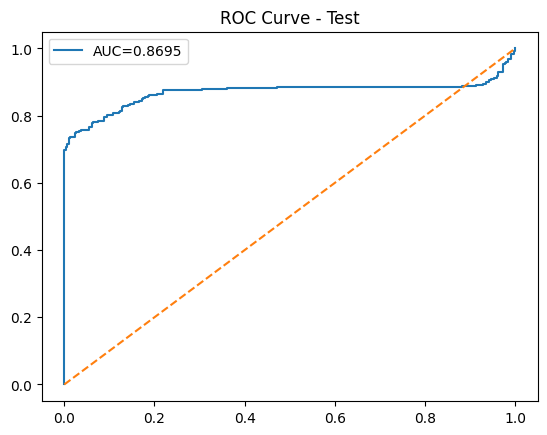

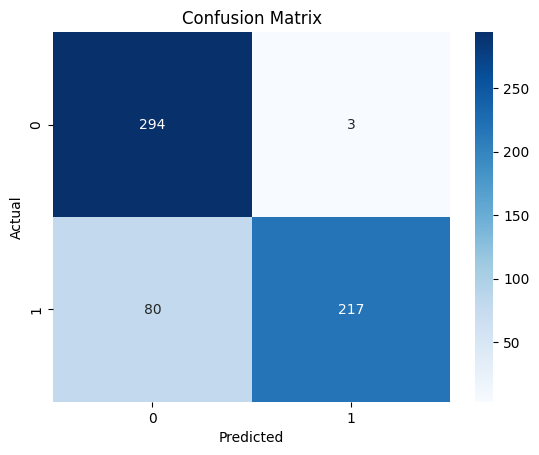

In [43]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve - Test")
plt.legend()
plt.show()

cm = confusion_matrix(test_labels, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

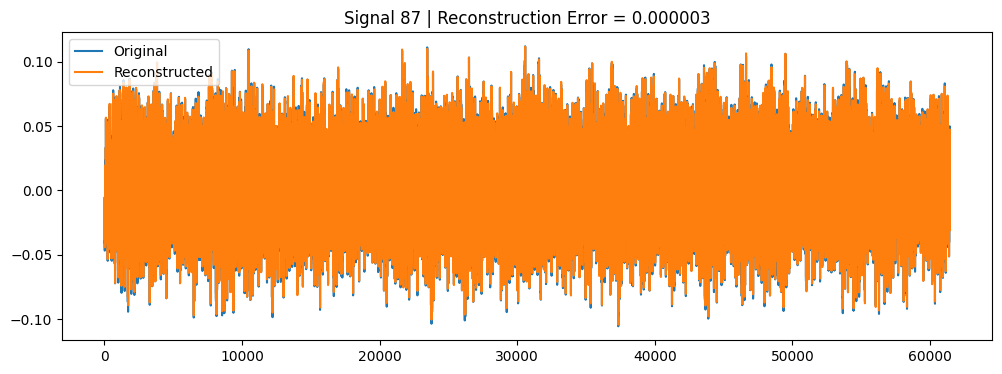

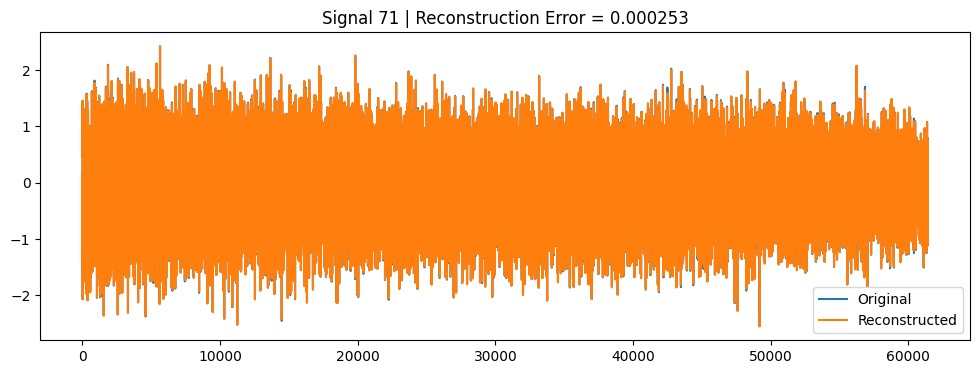

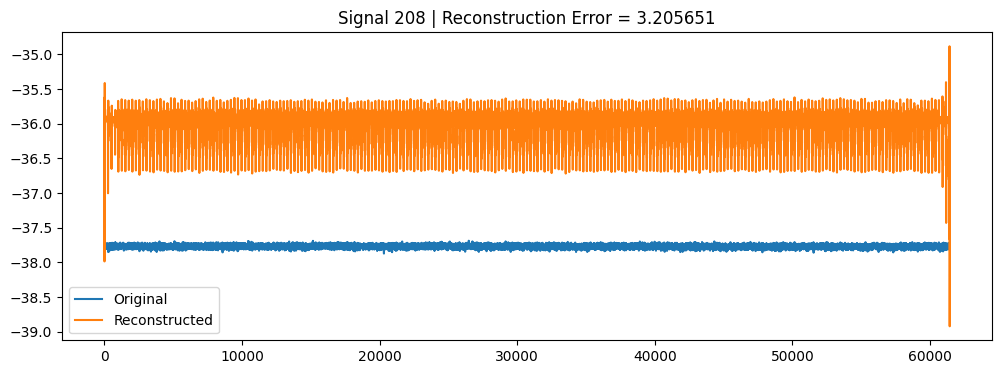

In [44]:
sorted_idx = np.argsort(test_scores)

best_idx = sorted_idx[0]
mid_idx  = sorted_idx[len(sorted_idx)//2]
worst_idx = sorted_idx[-1]

for idx in [best_idx, mid_idx, worst_idx]:

    original = X_test_raw[idx]

    reconstructed = reconstruct_full_signal(
        original,
        best_model,
        window_size,
        stride
    )

    error = np.mean((original - reconstructed) ** 2)

    plt.figure(figsize=(12,4))
    plt.plot(original, label="Original")
    plt.plot(reconstructed, label="Reconstructed")
    plt.title(f"Signal {idx} | Reconstruction Error = {error:.6f}")
    plt.legend()
    plt.show()